In [9]:
import sys
from pathlib import Path

current_dir = Path.cwd().resolve()
# walks upward until it finds a directory containing ppm/
PROJECT_ROOT = next(
    (p for p in (current_dir, *current_dir.parents) if (p / "ppm").is_dir()),
    current_dir,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from ppm.wandb_utils import load_multiple_experiments

plots_dir = PROJECT_ROOT / "plots/pre-training"
plots_dir.mkdir(parents=True, exist_ok=True)

In [10]:
PROJECTS=[
  "BPI12_001",
  "BPI12_002",
  "BPI12_003",
  "Distill_BPI12_001",
  "BPI15_001",
  "BPI15_002",
  "BPI15_003",
  "Distill_BPI15_001",
  "BPI17_001",
  "Distill_BPI17_001",
  "BPI17_002",
  "BPI17_003",
  "BPI19_001",
  "BPI19_002",
  "BPI19_003",
  "Distill_BPI19_001",  
  "BPI20_001",
  "BPI20_002",
  "BPI20_003",
  "Distill_BPI20_PTC_001",
  "Distill_BPI20_RFP_001",
  "Distill_BPI20_TPD_001",
  "Distill_BPI20_PTC_002",
  "Distill_BPI20_RFP_002",
  "Distill_BPI20_TPD_002",
  "LSTM_001",
  "baseline-nep" #not complete yet
]

runs_raw, _ = load_multiple_experiments(PROJECTS, force_update=False)


Database already exists: /app/visualization/paper/metrics/BPI12_001.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/paper/metrics/BPI12_002.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/paper/metrics/BPI12_003.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/paper/metrics/Distill_BPI12_001.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/paper/metrics/BPI15_001.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/paper/metrics/BPI15_002.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/paper/metrics/BPI15_003.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/paper/metrics/Distill_BPI15_001.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/paper/metric

In [11]:
import pandas as pd

pd.set_option("display.max_columns", None)   # show all columns
pd.set_option("display.width", None)         # don't wrap/truncate by width
pd.set_option("display.max_colwidth", None)  # optional: full cell content

runs_raw.columns

Index(['id', 'name', 'r', 'lr', 'log', 'device', 'epochs', 'compile',
       'n_heads', 'backbone',
       ...
       'train_next_activity_CE_loss', 'train_next_activity_KL_loss',
       'train_next_activity_total_loss', 'val_next_activity_CE_loss',
       'val_next_activity_KL_loss', 'val_next_activity_total_loss', 'seed',
       'prediction_table', 'transition_table',
       'best_test_final_next_activity_f1_macro'],
      dtype='str', length=118)

In [12]:
# preprocessing
runs = runs_raw.copy()

fine_tuning_col = "fine_tuning" if "fine_tuning" in runs.columns else "fine-tuning"
freeze_layers_col = "freeze_layers" if "freeze_layers" in runs.columns else "freeze-layers"

# ── identify backbone categories ──────────────────────────────────────────────
distill_mask = runs["project"].astype(str).str.startswith("Distill", na=False)
scratch_mask = (
    runs["backbone"].astype(str).str.contains("student", na=False)
    & ~distill_mask
)

# ── fine_tune normalization (all backbones) ───────────────────────────────────
runs["fine_tune"] = runs[fine_tuning_col]

mask_no_finetuning = (
    runs["fine_tune"].isna()
    | runs["fine_tune"].astype(str).str.strip().str.lower().isin(["none", "nan", ""])
)

runs.loc[mask_no_finetuning, "fine_tune"] = "no freezing"
runs.loc[mask_no_finetuning, freeze_layers_col] = "all"

# ── arch label helper ─────────────────────────────────────────────────────────
for col in ["hidden_size", "n_layers", "n_heads"]:
    if col in runs.columns:
        runs[col] = pd.to_numeric(runs[col], errors="coerce")

def _fmt_int(v):
    return str(int(v)) if pd.notna(v) else "nan"

def _arch_label(df: pd.DataFrame) -> pd.Series:
    hs = df["hidden_size"].map(_fmt_int).astype("string")
    nl = df["n_layers"].map(_fmt_int).astype("string")
    nh = df["n_heads"].map(_fmt_int).astype("string")
    return hs.str.cat([nl, nh], sep="_")

# ── rename backbones ──────────────────────────────────────────────────────────
runs.loc[scratch_mask,  "backbone"] = "nano_"    + _arch_label(runs.loc[scratch_mask])
runs.loc[distill_mask,  "backbone"] = "distill_" + _arch_label(runs.loc[distill_mask])

backbone_rename_map = {
    "BPI20PrepaidTravelCosts": "BPI20_PTC",
    "BPI20TravelPermitData":   "BPI20_TPD",
    "BPI20RequestForPayment":  "BPI20_RfP",
}
runs["log"] = runs["log"].replace(backbone_rename_map)

## Impact pre-training

In [13]:
METRIC = "best_test_final_next_activity_acc"
#METRIC = "best_test_final_next_activity_f1"

MODELS = [["gpt2-mini", "nano_512_4_8"], ["gpt2-small", "nano_768_12_12"]]

for col in ["categorical_features", "continuous_features"]:
    if col in runs.columns:
        runs[col] = runs[col].astype(str)

GROUP_COLS = ["log", "backbone", "fine_tune", "freeze_layers", "lr", "batch_size", "categorical_features", "continuous_features"]

EXTRA_COLS = ["project", "total_params", "trainable_params", "embedding_size"]
EXTRA_COLS = [c for c in EXTRA_COLS if c in runs.columns]  # only keep ones that exist

# Build df with everything we need
df = runs[GROUP_COLS + ["id", METRIC] + EXTRA_COLS].dropna(subset=[METRIC]).copy()
df[METRIC] = df[METRIC].astype(float)

# only retain relevant models
df = df[df["backbone"].isin([m for group in MODELS for m in group])]

# 1) Metric stats (ONLY from METRIC)
agg = (
    df.groupby(GROUP_COLS)[METRIC]
      .agg(["count", "mean", "std", "min", "max"])
      .rename(columns={
          "count": "n_runs",
          "mean": "acc_mean",
          "std": "acc_std",
          "min": "acc_min",
          "max": "acc_max",
      })
)

# 2) Add “descriptor” columns (not metric-related)
#    We assume these are constant within group; if not, we’ll detect it below.
descriptors = df.groupby(GROUP_COLS)[EXTRA_COLS].first() if EXTRA_COLS else None

# Optional: detect groups where descriptors are NOT constant
if EXTRA_COLS:
    nunique = df.groupby(GROUP_COLS)[EXTRA_COLS].nunique(dropna=False)
    bad = (nunique > 1).any(axis=1)
    if bad.any():
        print("Warning: some groups have varying descriptor values:")
        display(nunique[bad].reset_index())

# 3) Best run id per group (based on METRIC)
best_idx = df.groupby(GROUP_COLS)[METRIC].idxmax()
best_runs = df.loc[best_idx].set_index(GROUP_COLS)["id"].rename("best_run_id")

# 4) Combine
summary = agg
if descriptors is not None:
    summary = summary.join(descriptors)

summary = summary.join(best_runs).reset_index()
summary["n_runs"] = summary["n_runs"].astype(int)

for col in ["acc_mean", "acc_std", "acc_min", "acc_max"]:
    summary[col] = summary[col].map(lambda x: f"{x:.4f}")

summary = summary.sort_values(GROUP_COLS).reset_index(drop=True)

with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 200):
    display(summary)


,log,backbone,fine_tune,freeze_layers,lr,batch_size,categorical_features,continuous_features,n_runs,acc_mean,acc_std,acc_min,acc_max,project,total_params,trainable_params,embedding_size,best_run_id
0,BPI12,gpt2-mini,freeze,"1,-1",0.005,64.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.8146,0.0122,0.7978,0.8308,BPI12_001,38659623.0,6360103.0,512.0,a64vdfh8
1,BPI12,gpt2-small,freeze,"1,-1",0.005,64.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.8501,0.0055,0.8411,0.8548,BPI12_001,124522791.0,14258727.0,768.0,i0haxdho
2,BPI12,nano_512_4_8,no freezing,all,0.005,64.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.8537,0.0028,0.8495,0.8571,BPI12_002,13192743.0,13192743.0,512.0,w7ri7b29
3,BPI12,nano_768_12_12,no freezing,all,0.005,64.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.8570,0.0044,0.8498,0.8616,BPI12_002,85929255.0,85929255.0,768.0,gsn2yfzt
4,BPI15,gpt2-mini,freeze,"1,-1",0.005,64.0,"['activity', 'resource']",['accumulated_time'],5,0.0941,0.0388,0.0464,0.1393,BPI15_001,38798647.0,6499127.0,512.0,j87aw6jr
5,BPI15,gpt2-small,freeze,"1,-1",0.005,64.0,"['activity', 'resource']",['accumulated_time'],5,0.2038,0.0082,0.1914,0.2114,BPI15_001,124731191.0,14467127.0,768.0,bd3s8h0o
6,BPI15,nano_512_4_8,no freezing,all,0.005,64.0,"['activity', 'resource']",['accumulated_time'],5,0.1096,0.0443,0.0421,0.1450,BPI15_002,13331767.0,13331767.0,512.0,ugyrfosx
7,BPI15,nano_768_12_12,no freezing,all,0.005,64.0,"['activity', 'resource']",['accumulated_time'],5,0.0763,0.0228,0.0563,0.1124,BPI15_002,86137655.0,86137655.0,768.0,m3a4eptl
8,BPI17,gpt2-mini,freeze,"1,-1",0.005,64.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.8090,0.0127,0.7906,0.8252,BPI17_001,38706752.0,6407232.0,512.0,r67zv54x
9,BPI17,gpt2-small,freeze,"1,-1",0.005,64.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.8307,0.0064,0.8209,0.8383,BPI17_001,124593472.0,14329408.0,768.0,rm18pmpc


Saved: /app/plots/pre-training/Pretraining-gpt2-mini-nano_512_4_8.png
Wilcoxon results for gpt2-mini vs nano_512_4_8:
  Accuracy: W=0.0000, p=0.01562, n=7
  F1: W=0.0000, p=0.01562, n=7


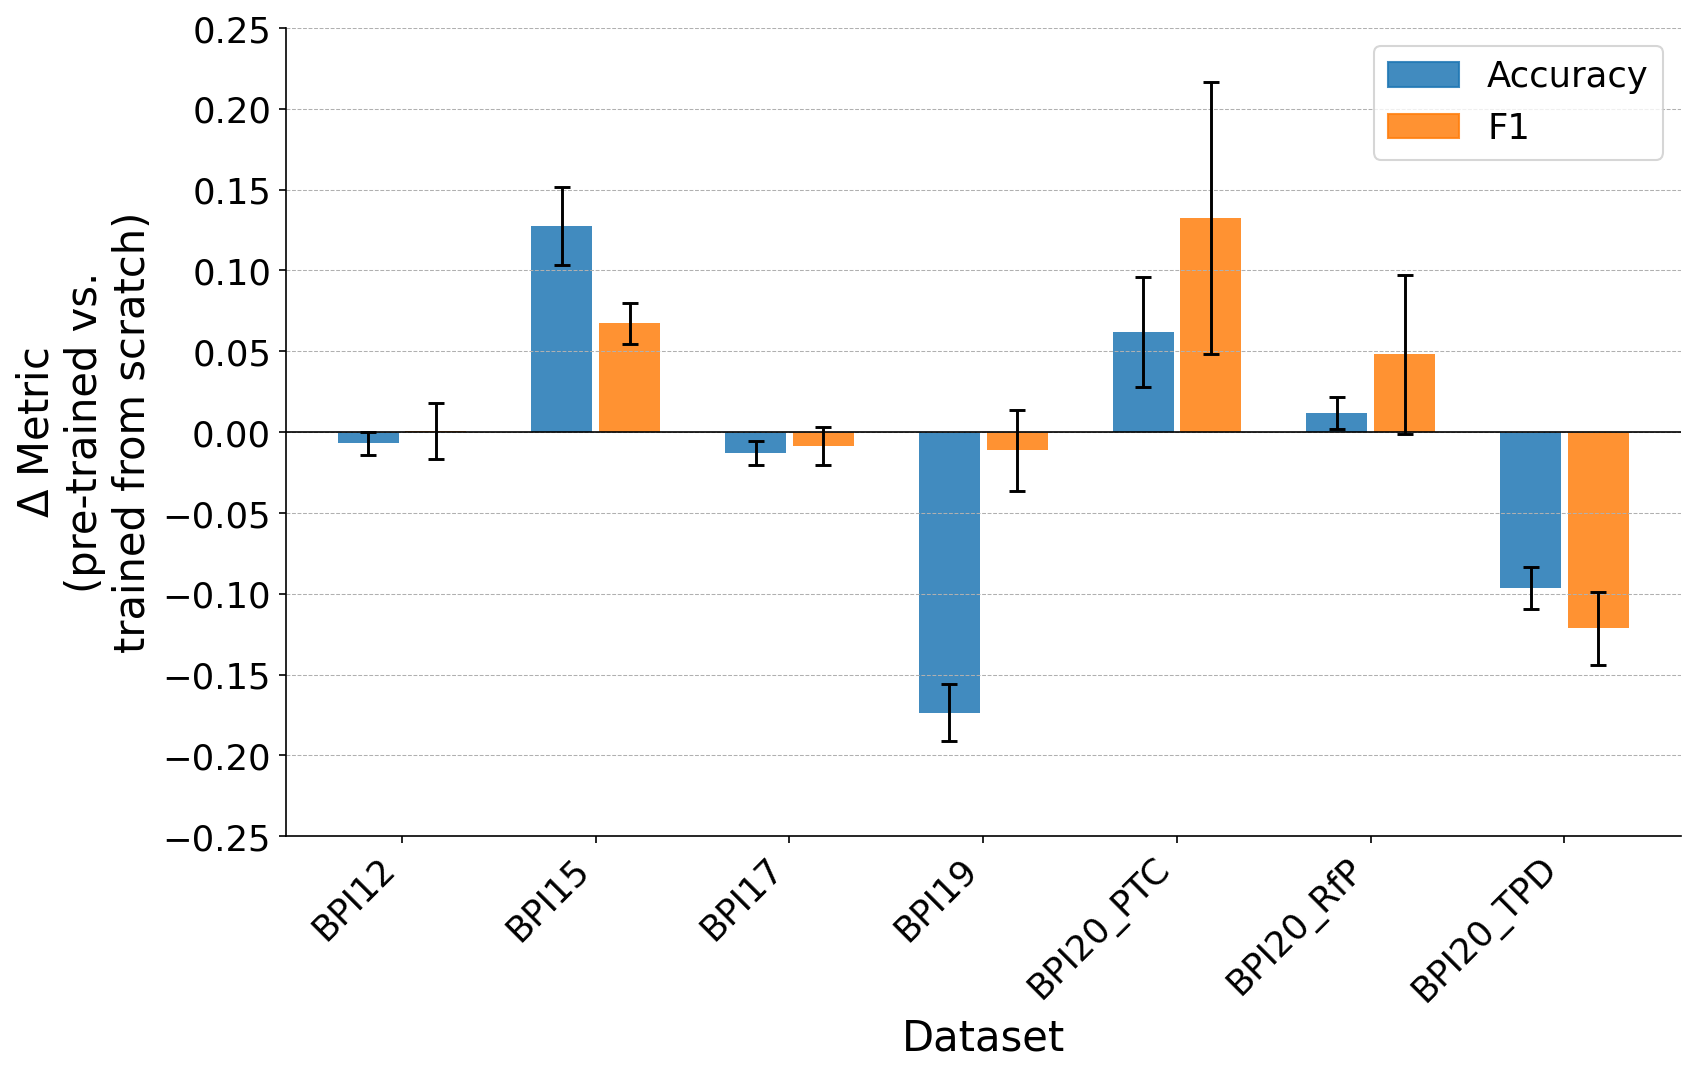

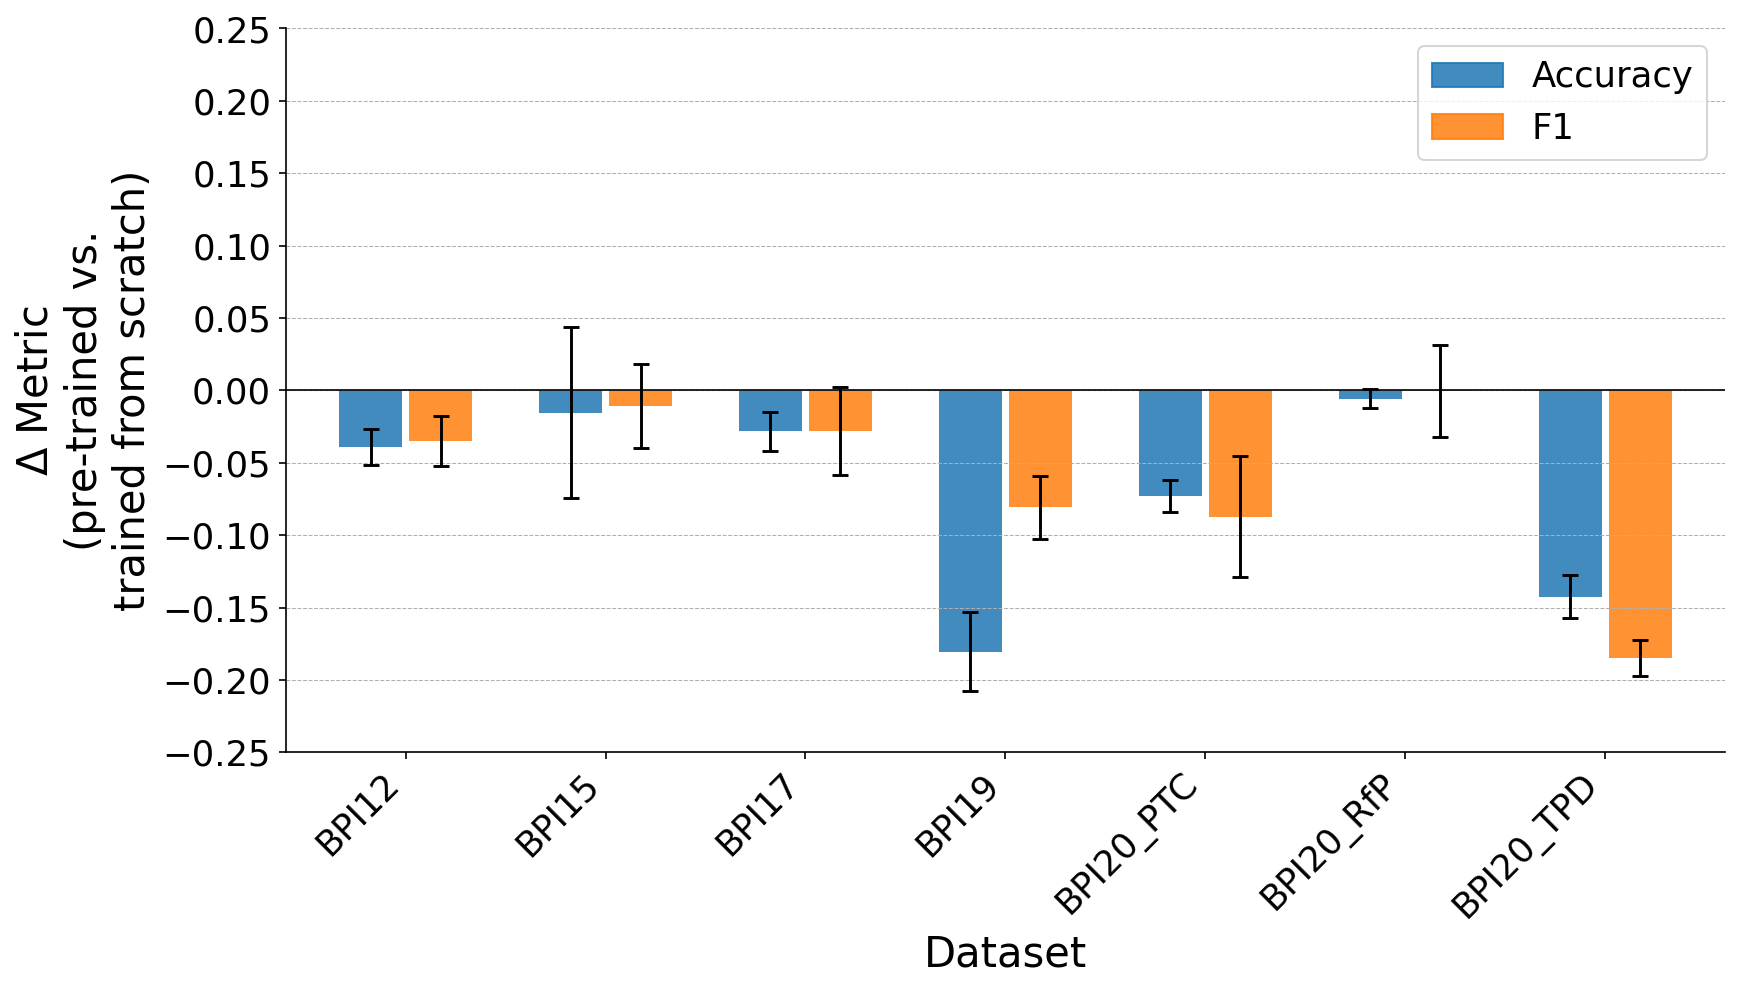

Saved: /app/plots/pre-training/Pretraining-gpt2-small-nano_768_12_12.png
Wilcoxon results for gpt2-small vs nano_768_12_12:
  Accuracy: W=12.0000, p=0.8125, n=7
  F1: W=11.0000, p=0.6875, n=7


<Figure size 960x720 with 0 Axes>

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

# ── config ────────────────────────────────────────────────────────────────────
METRICS = {
    "Accuracy": "best_test_final_next_activity_acc",
    "F1":       "best_test_final_next_activity_f1",
}
MODEL_GROUPS = [["gpt2-mini", "nano_512_4_8"], ["gpt2-small", "nano_768_12_12"]]
GROUP_COLS_PLOT = ["log", "backbone", "freeze_layers", "lr", "batch_size",
                   "categorical_features", "continuous_features"]

BAR_WIDTH = 0.35
DS_GAP    = 1.0
Y_TICK_STEP = 0.05

# ── build summary ─────────────────────────────────────────────────────────────
def build_summary(metric_col):
    all_models = [m for g in MODEL_GROUPS for m in g]
    df_ = runs[GROUP_COLS_PLOT + ["fine_tuning", metric_col]] \
            .dropna(subset=[metric_col]).copy()

    df_[metric_col] = df_[metric_col].astype(float)

    # keep only relevant backbones
    df_ = df_[df_["backbone"].isin(all_models)]

    # exclude "no freezing"
    df_ = df_[df_["fine_tuning"] != "no freezing"]

    return (df_.groupby(GROUP_COLS_PLOT)[metric_col]
               .agg(mean="mean", std="std")
               .reset_index())

summaries = {label: build_summary(col) for label, col in METRICS.items()}
datasets      = sorted(summaries["Accuracy"]["log"].unique())
n_ds          = len(datasets)
metric_labels = list(METRICS.keys())

# ── x layout ──────────────────────────────────────────────────────────────────
def cluster_center(di):
    return di * DS_GAP

def bar_x(di, mi):
    return cluster_center(di) + (mi - 0.5) * BAR_WIDTH

# ── matplotlib style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":     "DejaVu Sans",
    "font.size":       20,
    "axes.prop_cycle": plt.cycler("color", plt.cm.tab10.colors),
    "axes.labelsize":  20,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 17,
    "figure.dpi":      150,
})

TAB10         = plt.cm.tab10.colors
METRIC_COLORS = {"Accuracy": TAB10[0], "F1": TAB10[1]}
ERROR_KW = {"elinewidth": 1.4, "capsize": 4, "capthick": 1.4, "ecolor": "black"}

def print_wilcoxon_results(label, diffs_by_metric):
    print(f"Wilcoxon results for {label}:")
    for metric_label, diffs in diffs_by_metric.items():
        values = pd.Series(diffs, dtype=float).dropna()
        nonzero = values[~np.isclose(values, 0.0)]
        if len(values) == 0:
            print(f"  {metric_label}: skipped (no paired values)")
            continue
        if len(nonzero) == 0:
            print(f"  {metric_label}: skipped (all paired differences are zero, n={len(values)})")
            continue
        result = wilcoxon(values, zero_method="wilcox", alternative="two-sided", method="auto")
        print(f"  {metric_label}: W={result.statistic:.4f}, p={result.pvalue:.4g}, n={len(values)}")

# ── pass 1: build all figures, collect axes ───────────────────────────────────
figs_axes = []
all_diffs = []

for gpt_model, nano_model in MODEL_GROUPS:

    fig, ax = plt.subplots(figsize=(12, 7))
    diffs_by_metric = {metric_label: [] for metric_label in metric_labels}

    for di, ds in enumerate(datasets):
        for mi, metric_label in enumerate(metric_labels):
            sdf      = summaries[metric_label]
            gpt_row  = sdf[(sdf["log"] == ds) & (sdf["backbone"] == gpt_model)]
            nano_row = sdf[(sdf["log"] == ds) & (sdf["backbone"] == nano_model)]
            if gpt_row.empty or nano_row.empty:
                continue

            diff     = gpt_row["mean"].values[0] - nano_row["mean"].values[0]
            std_gpt  = gpt_row["std"].values[0]  if pd.notna(gpt_row["std"].values[0])  else 0
            std_nano = nano_row["std"].values[0]  if pd.notna(nano_row["std"].values[0]) else 0
            err      = np.sqrt(std_gpt**2 + std_nano**2)

            all_diffs.extend([float(diff - err), float(diff + err)])
            diffs_by_metric[metric_label].append(float(diff))
            ax.bar(
                bar_x(di, mi),
                diff,
                BAR_WIDTH * 0.9,
                yerr=err,
                color=METRIC_COLORS[metric_label],
                alpha=0.85,
                error_kw=ERROR_KW,
            )

    ax.axhline(0, color="black", linewidth=0.8)

    tick_pos = [cluster_center(di) for di in range(n_ds)]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(datasets, rotation=45, ha="right")
    ax.set_xlim(-DS_GAP * 0.6, (n_ds - 1) * DS_GAP + DS_GAP * 0.6)

    ax.set_ylabel("$\\Delta$ Metric\n(pre-trained vs.\ntrained from scratch)")
    ax.set_xlabel("Dataset")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5)
    ax.spines[["top", "right"]].set_visible(False)

    patches = [mpatches.Patch(color=METRIC_COLORS[m], alpha=0.85, label=m)
               for m in metric_labels]
    ax.legend(handles=patches)

    figs_axes.append((fig, ax, gpt_model, nano_model, diffs_by_metric))

# ── pass 2: align y-scales ────────────────────────────────────────────────────
if all_diffs:
    y_min_global = np.floor(min(all_diffs) / Y_TICK_STEP) * Y_TICK_STEP
    y_max_global = np.ceil(max(all_diffs) / Y_TICK_STEP) * Y_TICK_STEP
    if np.isclose(y_min_global, y_max_global):
        y_min_global -= Y_TICK_STEP
        y_max_global += Y_TICK_STEP
else:
    y_min_global, y_max_global = -Y_TICK_STEP, Y_TICK_STEP
yticks_global = np.arange(y_min_global, y_max_global + Y_TICK_STEP * 0.5, Y_TICK_STEP)
for _, ax, _, _, _ in figs_axes:
    ax.set_ylim(y_min_global, y_max_global)
    ax.set_yticks(yticks_global)

# ── pass 3: save and show ─────────────────────────────────────────────────────
for fig, ax, gpt_model, nano_model, diffs_by_metric in figs_axes:
    fig.tight_layout()
    fname = plots_dir / f"Pretraining-{gpt_model}-{nano_model}.png"
    fig.savefig(fname, bbox_inches="tight", dpi=150)
    print(f"Saved: {fname}")
    print_wilcoxon_results(f"{gpt_model} vs {nano_model}", diffs_by_metric)
    plt.figure(fig.number)
    plt.show()

In [15]:
METRIC = "best_test_final_next_activity_acc"
#METRIC = "best_test_final_next_activity_f1"

for col in ["categorical_features", "continuous_features"]:
    if col in runs.columns:
        runs[col] = runs[col].astype(str)

GROUP_COLS = ["log", "backbone", "fine_tune", "freeze_layers", "lr", "batch_size", "categorical_features", "continuous_features"]

EXTRA_COLS = ["project", "total_params", "trainable_params", "embedding_size"]
EXTRA_COLS = [c for c in EXTRA_COLS if c in runs.columns]

df = runs[GROUP_COLS + ["id", METRIC] + EXTRA_COLS].dropna(subset=[METRIC]).copy()
df[METRIC] = df[METRIC].astype(float)

# dynamically keep all nano and distill variants
df = df[df["backbone"].str.startswith("nano_") | df["backbone"].str.startswith("distill_")]

# 1) Metric stats
agg = (
    df.groupby(GROUP_COLS)[METRIC]
      .agg(["count", "mean", "std", "min", "max"])
      .rename(columns={
          "count": "n_runs",
          "mean":  "acc_mean",
          "std":   "acc_std",
          "min":   "acc_min",
          "max":   "acc_max",
      })
)

# 2) Descriptor columns
descriptors = df.groupby(GROUP_COLS)[EXTRA_COLS].first() if EXTRA_COLS else None

if EXTRA_COLS:
    nunique = df.groupby(GROUP_COLS)[EXTRA_COLS].nunique(dropna=False)
    bad = (nunique > 1).any(axis=1)
    if bad.any():
        print("Warning: some groups have varying descriptor values:")
        display(nunique[bad].reset_index())

# 3) Best run id per group
best_idx  = df.groupby(GROUP_COLS)[METRIC].idxmax()
best_runs = df.loc[best_idx].set_index(GROUP_COLS)["id"].rename("best_run_id")

# 4) Combine
summary = agg
if descriptors is not None:
    summary = summary.join(descriptors)
summary = summary.join(best_runs).reset_index()
summary["n_runs"] = summary["n_runs"].astype(int)

for col in ["acc_mean", "acc_std", "acc_min", "acc_max"]:
    summary[col] = summary[col].map(lambda x: f"{x:.4f}")

summary = summary.sort_values(GROUP_COLS).reset_index(drop=True)

with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 200):
    display(summary)

,log,backbone,fine_tune,freeze_layers,lr,batch_size,categorical_features,continuous_features,project,total_params,trainable_params,embedding_size
0,BPI20_PTC,distill_128_12_2,no freezing,all,0.005,512.0,"['activity', 'resource']",['accumulated_time'],2,1,1,1
1,BPI20_PTC,distill_128_4_2,no freezing,all,0.005,512.0,"['activity', 'resource']",['accumulated_time'],2,1,1,1
2,BPI20_PTC,distill_256_12_4,no freezing,all,0.005,512.0,"['activity', 'resource']",['accumulated_time'],2,1,1,1
3,BPI20_PTC,distill_256_4_4,no freezing,all,0.005,512.0,"['activity', 'resource']",['accumulated_time'],2,1,1,1
4,BPI20_PTC,distill_512_12_8,no freezing,all,0.005,512.0,"['activity', 'resource']",['accumulated_time'],2,1,1,1
5,BPI20_PTC,distill_512_4_8,no freezing,all,0.005,512.0,"['activity', 'resource']",['accumulated_time'],2,1,1,1
6,BPI20_PTC,distill_64_2_1,no freezing,all,0.005,512.0,"['activity', 'resource']",['accumulated_time'],2,1,1,1
7,BPI20_PTC,distill_64_4_1,no freezing,all,0.005,512.0,"['activity', 'resource']",['accumulated_time'],2,1,1,1
8,BPI20_PTC,distill_768_12_12,no freezing,all,0.005,512.0,"['activity', 'resource']",['accumulated_time'],2,1,1,1
9,BPI20_PTC,distill_768_4_12,no freezing,all,0.005,512.0,"['activity', 'resource']",['accumulated_time'],2,1,1,1


,log,backbone,fine_tune,freeze_layers,lr,batch_size,categorical_features,continuous_features,n_runs,acc_mean,acc_std,acc_min,acc_max,project,total_params,trainable_params,embedding_size,best_run_id
0,BPI12,distill_128_12_2,no freezing,all,0.005,512.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.8571,0.0053,0.8477,0.8608,Distill_BPI12_001,2410407.0,2410407.0,NaN,ic9z8m3k
1,BPI12,distill_128_4_2,no freezing,all,0.005,512.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.8568,0.0044,0.8490,0.8593,Distill_BPI12_001,824231.0,824231.0,NaN,001t7kmo
2,BPI12,distill_256_12_4,no freezing,all,0.005,512.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.8084,0.0544,0.7143,0.8440,Distill_BPI12_001,9539367.0,9539367.0,NaN,00evtudn
3,BPI12,distill_256_4_4,no freezing,all,0.005,512.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.8337,0.0168,0.8119,0.8555,Distill_BPI12_001,3221287.0,3221287.0,NaN,htdoo5fw
4,BPI12,distill_512_12_8,no freezing,all,0.005,512.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.7634,0.0621,0.6661,0.8182,Distill_BPI12_001,37953063.0,37953063.0,NaN,puqyaiep
5,BPI12,distill_512_4_8,no freezing,all,0.005,512.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.8086,0.0192,0.7812,0.8340,Distill_BPI12_001,12733991.0,12733991.0,NaN,9ea26f0v
6,BPI12,distill_64_2_1,no freezing,all,0.005,512.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.8595,0.0015,0.8570,0.8606,Distill_BPI12_001,115559.0,115559.0,NaN,2s25kfrx
7,BPI12,distill_64_4_1,no freezing,all,0.005,512.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.8589,0.0031,0.8535,0.8613,Distill_BPI12_001,215527.0,215527.0,NaN,35b4idkn
8,BPI12,distill_768_12_12,no freezing,all,0.005,512.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.7196,0.0548,0.6647,0.7900,Distill_BPI12_001,85241127.0,85241127.0,NaN,tzte2w1m
9,BPI12,distill_768_4_12,no freezing,all,0.005,512.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.8049,0.0169,0.7774,0.8191,Distill_BPI12_001,28538151.0,28538151.0,NaN,3kq5x9rq


Saved: /app/plots/pre-training/Distill-vs-Nano_by-dataset.png
Wilcoxon results for Distill vs Nano by dataset:
  Accuracy: W=0.0000, p=0.01562, n=7
  F1: W=0.0000, p=0.01562, n=7


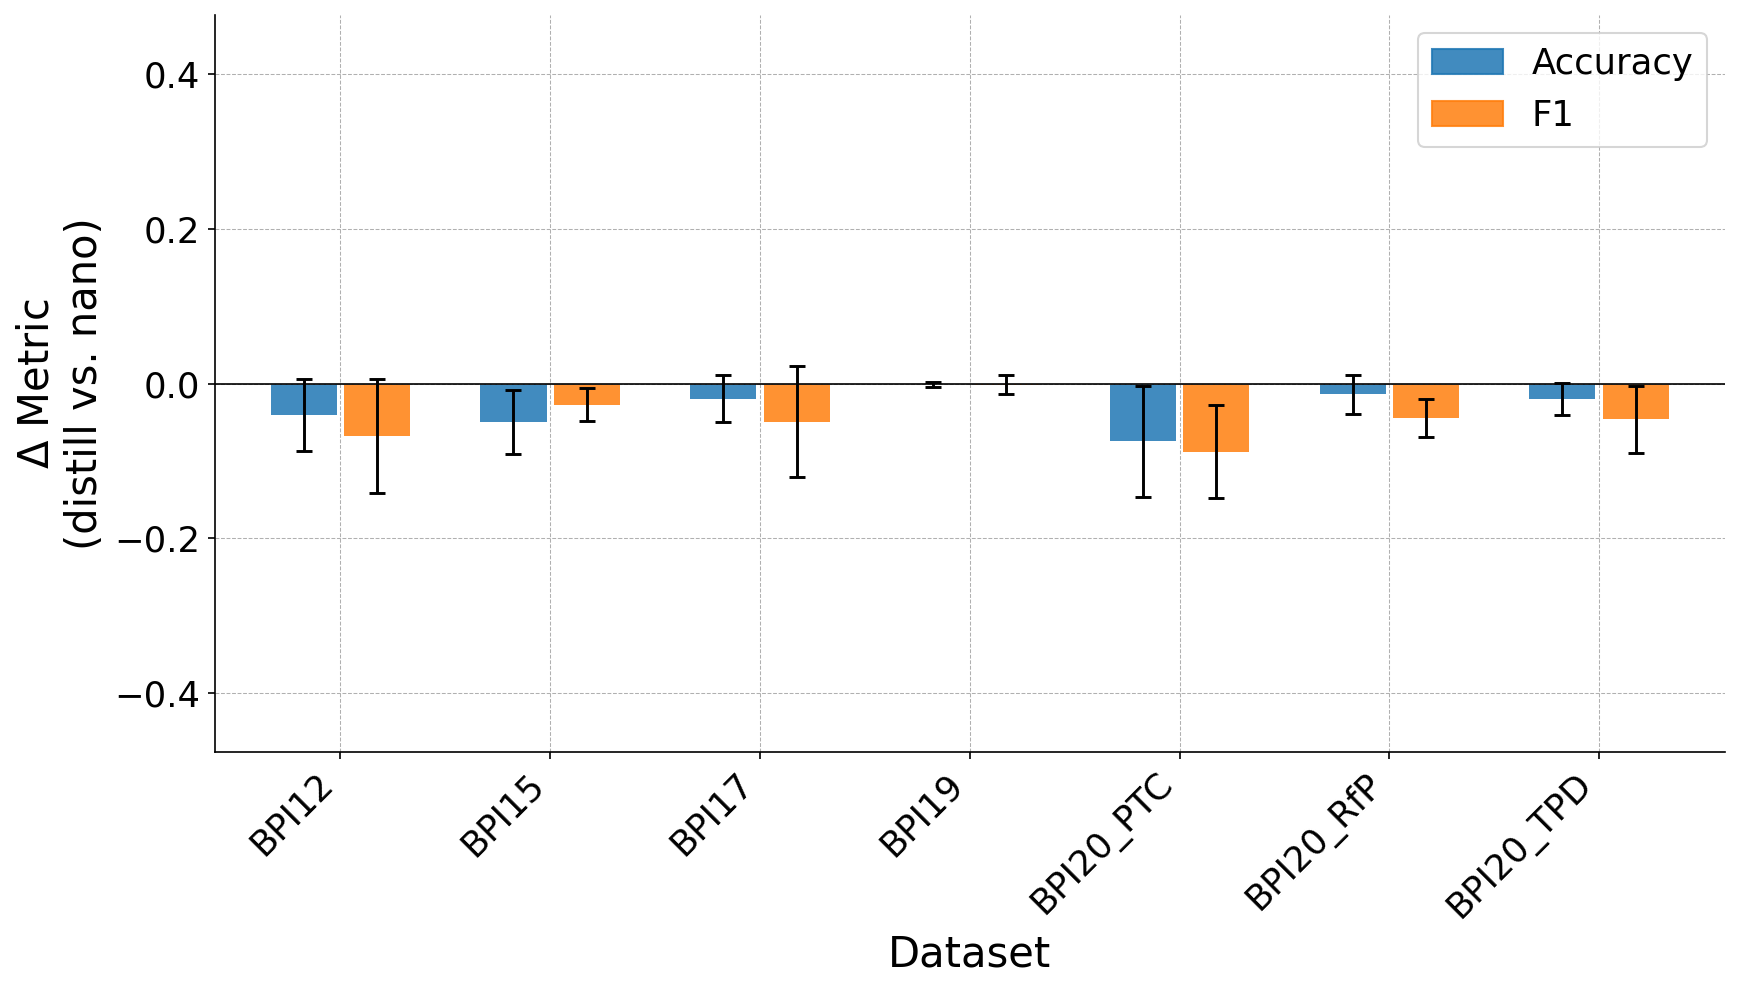

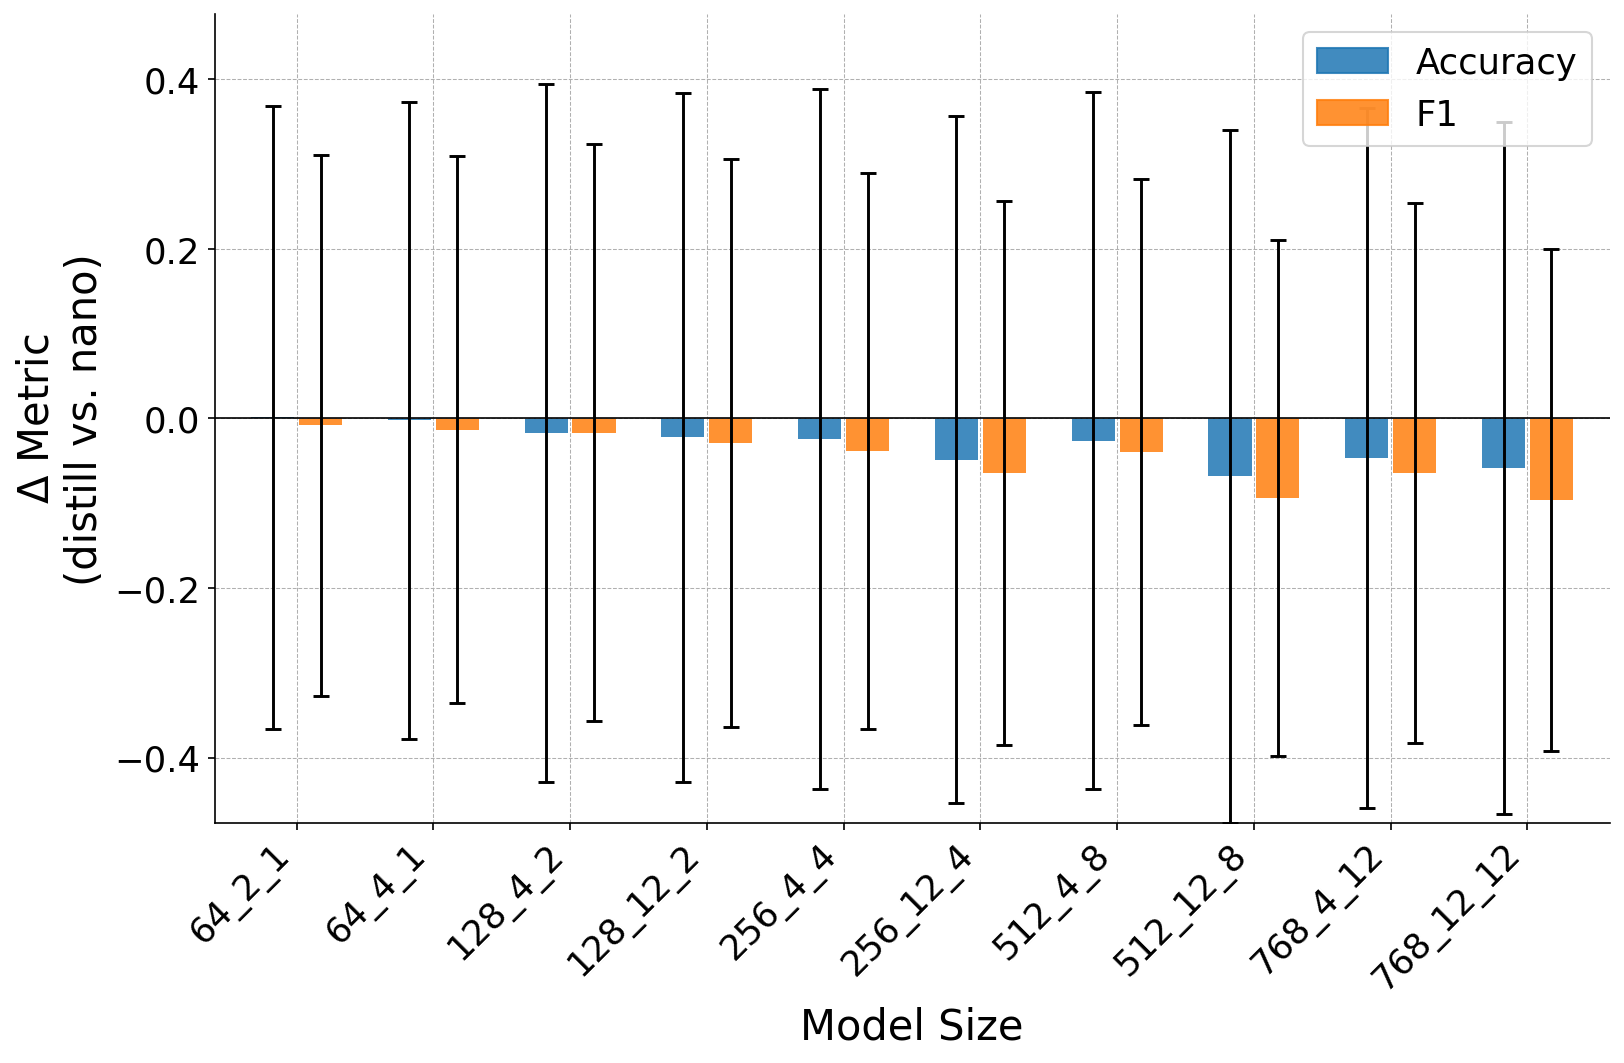

Saved: /app/plots/pre-training/Distill-vs-Nano_by-size.png
Wilcoxon results for Distill vs Nano by size:
  Accuracy: W=1.0000, p=0.003906, n=10
  F1: W=0.0000, p=0.001953, n=10
Saved: /app/plots/pre-training/LLM-vs-LSTM_by-dataset_Acc-F1.png
Wilcoxon results for LLM vs LSTM by dataset:
  Accuracy: W=1.0000, p=0.03125, n=7
  F1: W=7.0000, p=0.2969, n=7


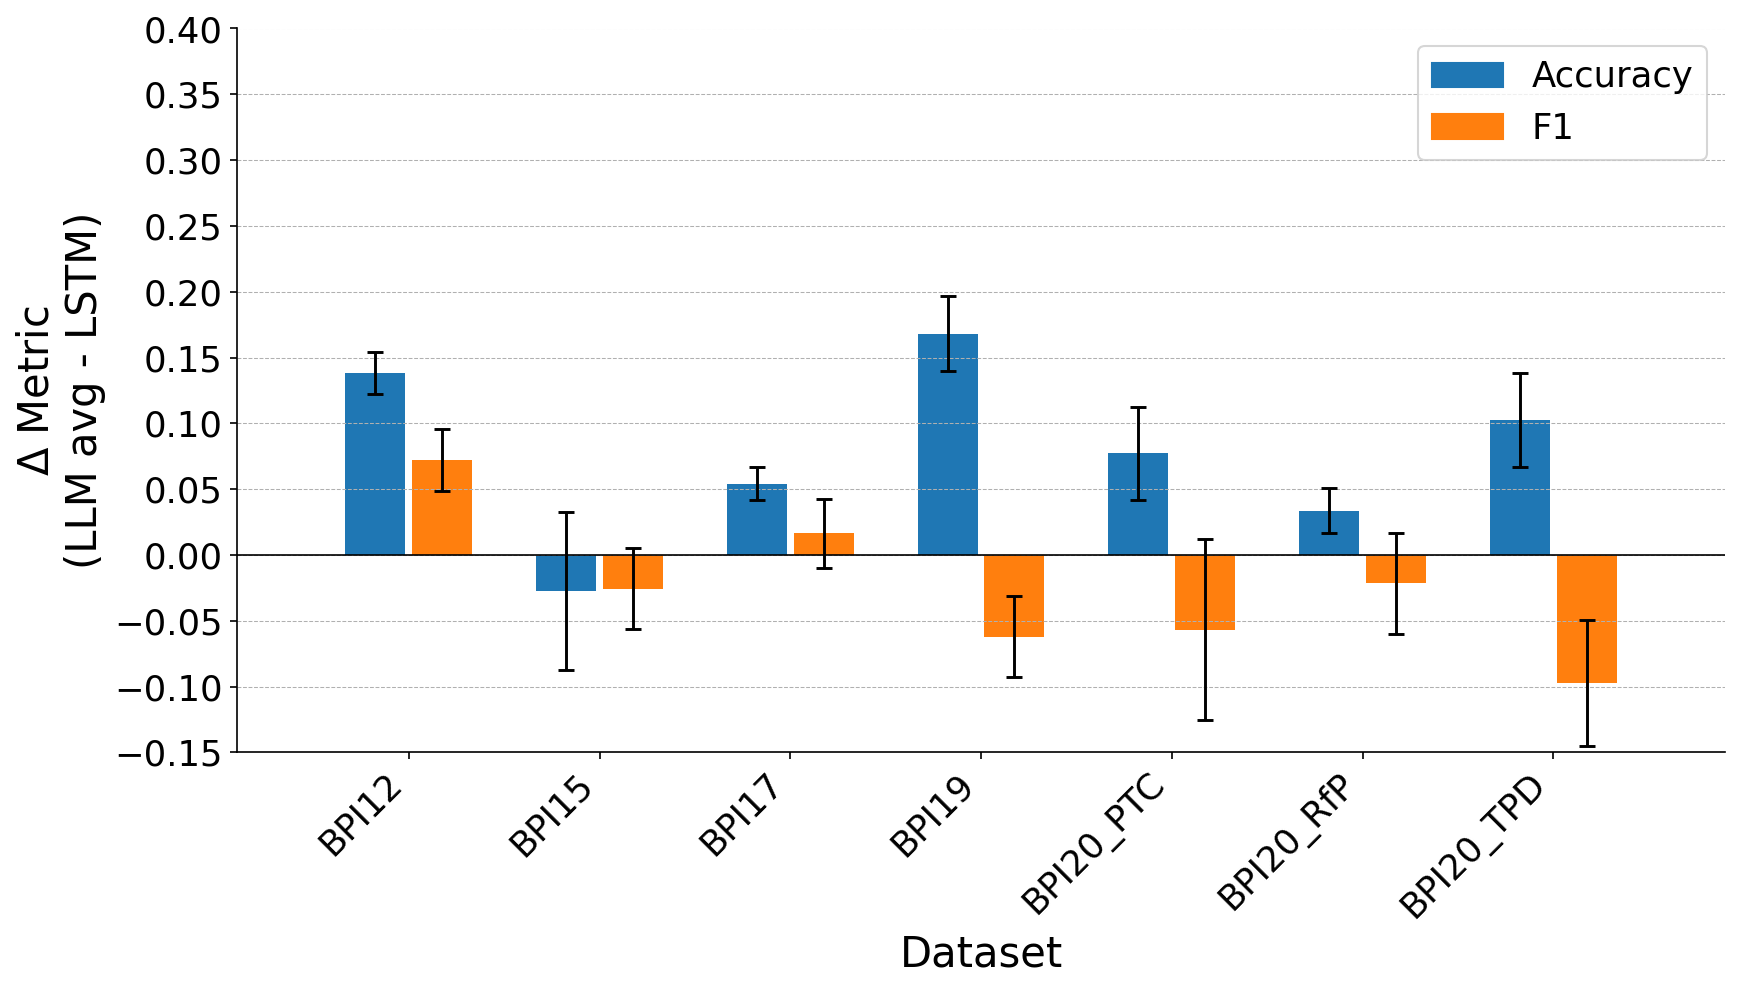

Saved: /app/plots/pre-training/LLM-vs-Baseline_by-dataset_Acc-F1.png
Wilcoxon results for LLM vs Argmax by dataset:
  Accuracy: W=9.0000, p=0.4688, n=7
  F1: W=10.0000, p=0.5781, n=7


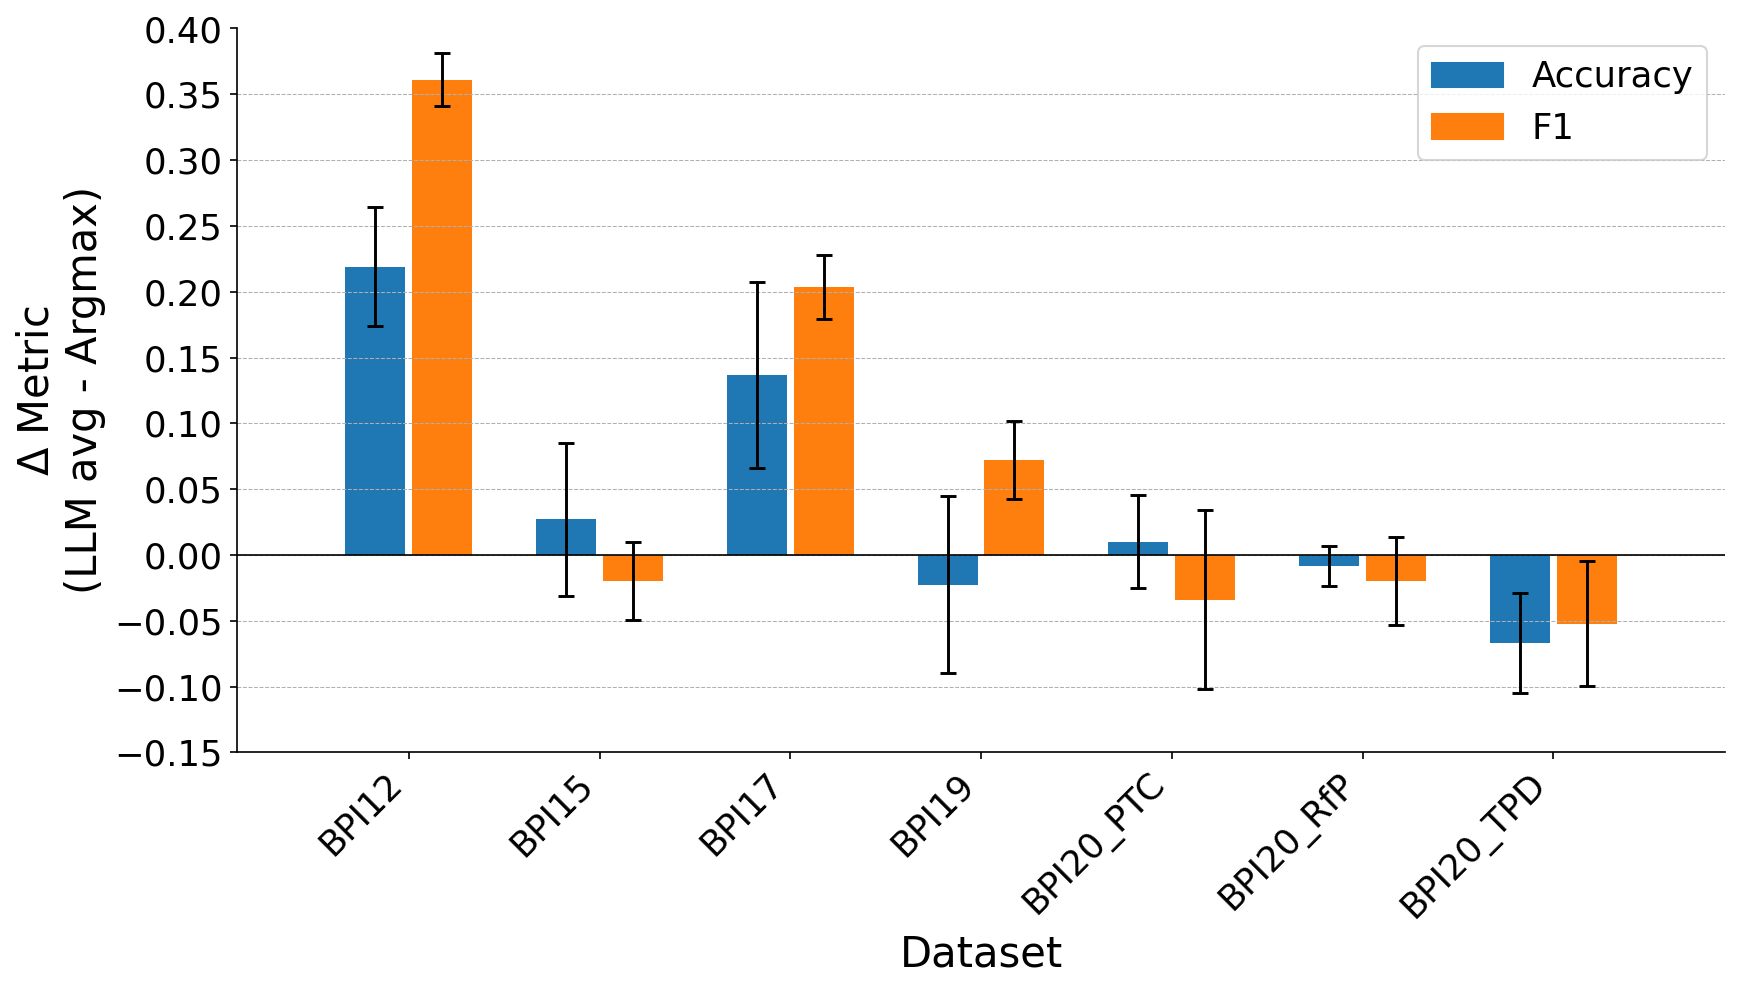

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

METRICS = {
    "Accuracy": "best_test_final_next_activity_acc",
    "F1":       "best_test_final_next_activity_f1",
}

BAR_WIDTH = 0.35
DS_GAP    = 1.0

TAB10         = plt.cm.tab10.colors
METRIC_COLORS = {"Accuracy": TAB10[0], "F1": TAB10[1]}
ERROR_KW = {"elinewidth": 1.4, "capsize": 4, "capthick": 1.4, "ecolor": "black"}

def print_wilcoxon_results(label, diffs_by_metric):
    print(f"Wilcoxon results for {label}:")
    for metric_label, diffs in diffs_by_metric.items():
        values = pd.Series(diffs, dtype=float).dropna()
        nonzero = values[~np.isclose(values, 0.0)]
        if len(values) == 0:
            print(f"  {metric_label}: skipped (no paired values)")
            continue
        if len(nonzero) == 0:
            print(f"  {metric_label}: skipped (all paired differences are zero, n={len(values)})")
            continue
        result = wilcoxon(values, zero_method="wilcox", alternative="two-sided", method="auto")
        print(f"  {metric_label}: W={result.statistic:.4f}, p={result.pvalue:.4g}, n={len(values)}")

plt.rcParams.update({
    "font.family":     "DejaVu Sans",
    "font.size":       20,
    "axes.prop_cycle": plt.cycler("color", plt.cm.tab10.colors),
    "axes.labelsize":  20,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 17,
    "figure.dpi":      150,
})

def sort_sizes(sizes):
    def size_key(s):
        try:
            return tuple(int(x) for x in s.split("_"))
        except:
            return (0,)
    return sorted(sizes, key=size_key)

def cluster_center(di): return di * DS_GAP
def bar_x(di, mi):      return cluster_center(di) + (mi - 0.5) * BAR_WIDTH

def build_diff_by_dataset():
    """For each (log, size), compute diff. Then average over sizes per log."""
    records = []
    for metric_label, metric_col in METRICS.items():
        df_ = runs[["log", "backbone", metric_col]].dropna(subset=[metric_col]).copy()
        df_[metric_col] = df_[metric_col].astype(float)

        nano_df    = df_[df_["backbone"].str.startswith("nano_")].copy()
        distill_df = df_[df_["backbone"].str.startswith("distill_")].copy()

        nano_df["size"]    = nano_df["backbone"].str.removeprefix("nano_")
        distill_df["size"] = distill_df["backbone"].str.removeprefix("distill_")

        all_sizes = set(nano_df["size"].unique()) & set(distill_df["size"].unique())

        for size in all_sizes:
            nano_s    = nano_df[nano_df["size"] == size]
            distill_s = distill_df[distill_df["size"] == size]

            common_logs = set(nano_s["log"].unique()) & set(distill_s["log"].unique())
            if not common_logs:
                continue

            for log in common_logs:
                nano_mean    = nano_s[nano_s["log"] == log][metric_col].mean()
                distill_mean = distill_s[distill_s["log"] == log][metric_col].mean()
                records.append({
                    "log":    log,
                    "size":   size,
                    "metric": metric_label,
                    "diff":   distill_mean - nano_mean,
                })

    return pd.DataFrame(records)

def build_diff_by_size():
    """For each size, find common logs, average per log, then average across logs."""
    records = []
    for metric_label, metric_col in METRICS.items():
        df_ = runs[["log", "backbone", metric_col]].dropna(subset=[metric_col]).copy()
        df_[metric_col] = df_[metric_col].astype(float)

        nano_df    = df_[df_["backbone"].str.startswith("nano_")].copy()
        distill_df = df_[df_["backbone"].str.startswith("distill_")].copy()

        nano_df["size"]    = nano_df["backbone"].str.removeprefix("nano_")
        distill_df["size"] = distill_df["backbone"].str.removeprefix("distill_")

        all_sizes = set(nano_df["size"].unique()) & set(distill_df["size"].unique())

        for size in all_sizes:
            nano_s    = nano_df[nano_df["size"] == size]
            distill_s = distill_df[distill_df["size"] == size]

            common_logs = set(nano_s["log"].unique()) & set(distill_s["log"].unique())
            if not common_logs:
                continue

            nano_s    = nano_s[nano_s["log"].isin(common_logs)]
            distill_s = distill_s[distill_s["log"].isin(common_logs)]

            nano_per_log    = nano_s.groupby("log")[metric_col].mean()
            distill_per_log = distill_s.groupby("log")[metric_col].mean()

            nano_mean    = nano_per_log.mean()
            distill_mean = distill_per_log.mean()
            nano_std     = nano_per_log.std()
            distill_std  = distill_per_log.std()

            records.append({
                "size":   size,
                "metric": metric_label,
                "diff":   distill_mean - nano_mean,
                "err":    np.sqrt((nano_std or 0)**2 + (distill_std or 0)**2),
            })

    return pd.DataFrame(records)

# ── FIGURE 1: x = datasets, average over all model sizes ─────────────────────
raw1 = build_diff_by_dataset()
agg1 = (
    raw1.groupby(["log", "metric"])
    .agg(diff=("diff", "mean"), err=("diff", "std"))
    .reset_index()
)
agg1["err"] = agg1["err"].fillna(0)

datasets      = sorted(agg1["log"].unique())
n_ds          = len(datasets)
metric_labels = list(METRICS.keys())

fig1, ax1 = plt.subplots(figsize=(12, 7))

for di, ds in enumerate(datasets):
    for mi, metric_label in enumerate(metric_labels):
        row = agg1[(agg1["log"] == ds) & (agg1["metric"] == metric_label)]
        if row.empty:
            continue
        ax1.bar(
            bar_x(di, mi),
            row["diff"].values[0],
            BAR_WIDTH * 0.9,
            yerr=row["err"].values[0],
            color=METRIC_COLORS[metric_label],
            alpha=0.85,
            error_kw=ERROR_KW,
        )

ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_xticks([cluster_center(di) for di in range(n_ds)])
ax1.set_xticklabels(datasets, rotation=45, ha="right")
ax1.set_xlim(-DS_GAP * 0.6, (n_ds - 1) * DS_GAP + DS_GAP * 0.6)
ax1.set_ylabel("$\\Delta$ Metric\n(distill vs. nano)")
ax1.set_xlabel("Dataset")
ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
ax1.spines[["top", "right"]].set_visible(False)
ax1.legend(handles=[mpatches.Patch(color=METRIC_COLORS[m], alpha=0.85, label=m) for m in metric_labels])

# ── FIGURE 2: x = model sizes, average over all datasets ─────────────────────
agg2 = build_diff_by_size()
sizes   = sort_sizes(agg2["size"].unique())
n_sizes = len(sizes)

fig2, ax2 = plt.subplots(figsize=(12, 7))

for si, size in enumerate(sizes):
    for mi, metric_label in enumerate(metric_labels):
        row = agg2[(agg2["size"] == size) & (agg2["metric"] == metric_label)]
        if row.empty:
            continue
        ax2.bar(
            bar_x(si, mi),
            row["diff"].values[0],
            BAR_WIDTH * 0.9,
            yerr=row["err"].values[0],
            color=METRIC_COLORS[metric_label],
            alpha=0.85,
            error_kw=ERROR_KW,
        )

ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xticks([cluster_center(si) for si in range(n_sizes)])
ax2.set_xticklabels(sizes, rotation=45, ha="right")
ax2.set_xlim(-DS_GAP * 0.6, (n_sizes - 1) * DS_GAP + DS_GAP * 0.6)
ax2.set_ylabel("$\\Delta$ Metric\n(distill vs. nano)")
ax2.set_xlabel("Model Size")
ax2.grid(True, which="both", linestyle="--", linewidth=0.5)
ax2.spines[["top", "right"]].set_visible(False)
ax2.legend(handles=[mpatches.Patch(color=METRIC_COLORS[m], alpha=0.85, label=m) for m in metric_labels])

# ── align y-scales ────────────────────────────────────────────────────────────
pair12_vals = pd.concat([
    agg1["diff"] - agg1["err"],
    agg1["diff"] + agg1["err"],
    agg2["diff"] - agg2["err"],
    agg2["diff"] + agg2["err"],
], ignore_index=True).dropna()
yabs = max(abs(float(pair12_vals.min())), abs(float(pair12_vals.max()))) if not pair12_vals.empty else 0.05
yabs = max(yabs, 0.05)
ax1.set_ylim(-yabs, yabs)
ax2.set_ylim(-yabs, yabs)

fig1_wilcoxon = {
    metric_label: agg1.loc[agg1["metric"] == metric_label, "diff"].tolist()
    for metric_label in metric_labels
}

fig1.tight_layout()
fname1 = plots_dir / "Distill-vs-Nano_by-dataset.png"
fig1.savefig(fname1, bbox_inches="tight", dpi=150)
print(f"Saved: {fname1}")
print_wilcoxon_results("Distill vs Nano by dataset", fig1_wilcoxon)
plt.show()

fig2_wilcoxon = {
    metric_label: agg2.loc[agg2["metric"] == metric_label, "diff"].tolist()
    for metric_label in metric_labels
}

fig2.tight_layout()
fname2 = plots_dir / "Distill-vs-Nano_by-size.png"
fig2.savefig(fname2, bbox_inches="tight", dpi=150)
print(f"Saved: {fname2}")
print_wilcoxon_results("Distill vs Nano by size", fig2_wilcoxon)
plt.show()

# New FIGURE 3/4: GPT+Qwen vs LSTM/Argmax (split by metric)
REFS = [("vs LSTM", "lstm"), ("vs Argmax", "argmax")]

def _is_llm_backbone(series):
    s = series.astype(str).str.lower()
    return s.str.contains("gpt") | s.str.contains("qwen")

def _is_lstm_row(df):
    back = df["backbone"].astype(str).str.lower() if "backbone" in df.columns else pd.Series(False, index=df.index)
    proj = df["project"].astype(str).str.lower() if "project" in df.columns else pd.Series(False, index=df.index)
    return back.str.contains("lstm") | proj.str.contains("lstm")

def _is_argmax_row(df):
    back = df["backbone"].astype(str).str.lower() if "backbone" in df.columns else pd.Series(False, index=df.index)
    proj = df["project"].astype(str).str.lower() if "project" in df.columns else pd.Series(False, index=df.index)
    # baseline-nep currently stores this as baseline_transition_frequency.
    return (
        back.str.contains("argmax|baseline|transition_frequency|most_frequent|majority")
        | proj.str.contains("baseline")
    )

def _metric_frame(metric_label, metric_col):
    # Some baselines log legacy metric names (e.g., *_acc, *_f1_macro).
    fallback_cols = {
        "Accuracy": ["best_test_final_next_activity_acc"],
        "F1": ["best_test_final_next_activity_f1_macro"],
    }.get(metric_label, [])

    candidate_cols = [metric_col] + [c for c in fallback_cols if c != metric_col]
    cols = [c for c in ["log", "backbone", "project"] + candidate_cols if c in runs.columns]
    df = runs[cols].copy()

    present_metric_cols = [c for c in candidate_cols if c in df.columns]
    if not present_metric_cols:
        return pd.DataFrame(columns=["log", "backbone", "project", metric_col])

    # Prefer canonical metric_col, fill missing values from fallbacks.
    df[metric_col] = pd.to_numeric(df[present_metric_cols[0]], errors="coerce")
    for c in present_metric_cols[1:]:
        df[metric_col] = df[metric_col].fillna(pd.to_numeric(df[c], errors="coerce"))

    return df[["log", "backbone", "project", metric_col]].dropna(subset=[metric_col]).copy()

def build_llm_vs_refs_by_log():
    records = []
    for metric_label, metric_col in METRICS.items():
        df = _metric_frame(metric_label, metric_col)

        llm_df = df[_is_llm_backbone(df["backbone"])].copy()
        lstm_df = df[_is_lstm_row(df)].copy()
        argm_df = df[_is_argmax_row(df)].copy()

        llm_mean = llm_df.groupby("log")[metric_col].mean()
        llm_std = llm_df.groupby("log")[metric_col].std().fillna(0)
        lstm_mean = lstm_df.groupby("log")[metric_col].mean()
        lstm_std = lstm_df.groupby("log")[metric_col].std().fillna(0)
        argm_mean = argm_df.groupby("log")[metric_col].mean()
        argm_std = argm_df.groupby("log")[metric_col].std().fillna(0)

        for log in sorted(llm_mean.index):
            if log in lstm_mean.index:
                records.append({
                    "log": log,
                    "metric": metric_label,
                    "ref": "vs LSTM",
                    "diff": llm_mean[log] - lstm_mean[log],
                    "err": np.sqrt(float(llm_std.get(log, 0))**2 + float(lstm_std.get(log, 0))**2),
                })
            if log in argm_mean.index:
                records.append({
                    "log": log,
                    "metric": metric_label,
                    "ref": "vs Argmax",
                    "diff": llm_mean[log] - argm_mean[log],
                    "err": np.sqrt(float(llm_std.get(log, 0))**2 + float(argm_std.get(log, 0))**2),
                })

    return pd.DataFrame(records)

BAR_COLORS = {"Accuracy": TAB10[0], "F1": TAB10[1]}

def _plot_two_bar_group_by_ref(ax, logs, df_plot, ref_label):
    metrics = ["Accuracy", "F1"]
    for i, log in enumerate(logs):
        for j, metric_label in enumerate(metrics):
            row = df_plot[(df_plot["log"] == log) & (df_plot["metric"] == metric_label) & (df_plot["ref"] == ref_label)]
            if row.empty:
                continue
            x = cluster_center(i) + (j - 0.5) * BAR_WIDTH
            ax.bar(
                x,
                row["diff"].values[0],
                BAR_WIDTH * 0.9,
                yerr=row["err"].values[0],
                color=BAR_COLORS[metric_label],
                error_kw=ERROR_KW,
            )

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks([cluster_center(i) for i in range(len(logs))])
    ax.set_xticklabels(logs, rotation=45, ha="right")
    ax.set_xlim(-DS_GAP * 0.9, (len(logs) - 1) * DS_GAP + DS_GAP * 0.9)
    ax.set_ylabel("$\\Delta$ Metric\n" f"(LLM avg - {ref_label.replace('vs ', '')})")
    ax.set_xlabel("Dataset")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(handles=[
        mpatches.Patch(color=BAR_COLORS["Accuracy"], label="Accuracy"),
        mpatches.Patch(color=BAR_COLORS["F1"], label="F1"),
    ])

# FIGURE 3/4: x = logs, split by reference baseline
agg3 = build_llm_vs_refs_by_log()
if not agg3.empty:
    logs3 = sorted(agg3["log"].unique())
    pair34_vals = pd.concat([
        agg3["diff"] - agg3["err"],
        agg3["diff"] + agg3["err"],
    ], ignore_index=True).dropna()
    y_min34 = np.floor(float(pair34_vals.min()) / 0.05) * 0.05 if not pair34_vals.empty else -0.05
    y_max34 = np.ceil(float(pair34_vals.max()) / 0.05) * 0.05 if not pair34_vals.empty else 0.05
    if np.isclose(y_min34, y_max34):
        y_min34 -= 0.05
        y_max34 += 0.05
    yticks34 = np.arange(y_min34, y_max34 + 0.025, 0.05)

    fig3a, ax3a = plt.subplots(figsize=(12, 7))
    _plot_two_bar_group_by_ref(ax3a, logs3, agg3, "vs LSTM")
    ax3a.set_ylim(y_min34, y_max34)
    ax3a.set_yticks(yticks34)
    fig3a_wilcoxon = {
        metric_label: agg3.loc[(agg3["ref"] == "vs LSTM") & (agg3["metric"] == metric_label), "diff"].tolist()
        for metric_label in metric_labels
    }

    fig3a.tight_layout()
    fname3a = plots_dir / "LLM-vs-LSTM_by-dataset_Acc-F1.png"
    fig3a.savefig(fname3a, bbox_inches="tight", dpi=150)
    print(f"Saved: {fname3a}")
    print_wilcoxon_results("LLM vs LSTM by dataset", fig3a_wilcoxon)
    plt.show()

    fig3b, ax3b = plt.subplots(figsize=(12, 7))
    _plot_two_bar_group_by_ref(ax3b, logs3, agg3, "vs Argmax")
    ax3b.set_ylim(y_min34, y_max34)
    ax3b.set_yticks(yticks34)
    fig3b_wilcoxon = {
        metric_label: agg3.loc[(agg3["ref"] == "vs Argmax") & (agg3["metric"] == metric_label), "diff"].tolist()
        for metric_label in metric_labels
    }

    fig3b.tight_layout()
    fname3b = plots_dir / "LLM-vs-Baseline_by-dataset_Acc-F1.png"
    fig3b.savefig(fname3b, bbox_inches="tight", dpi=150)
    print(f"Saved: {fname3b}")
    print_wilcoxon_results("LLM vs Argmax by dataset", fig3b_wilcoxon)
    plt.show()
else:
    print("Skipped LLM-vs-baseline plots: no overlap between GPT/Qwen and LSTM/Argmax baselines.")